In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
import os
import kagglehub

warnings.filterwarnings("ignore")

# Plot settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lava18/google-play-store-apps")

print("Path to dataset files:", path)

100%|██████████| 1.94M/1.94M [00:01<00:00, 1.58MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lava18/google-play-store-apps/versions/6


In [ ]:
import pandas as pd
import os

df = pd.read_csv(os.path.join(path,"googleplaystore.csv"))

df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 10841
Columns : 13


In [ ]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
df.describe(include='object')

,App,Category,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,596,1695,1579,10039,10040,8714,842,326,1459,2451


In [ ]:
df.sample(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
8111,Phone Clean Best Speed Booster,PRODUCTIVITY,4.5,81502,Varies with device,"1,000,000+",Free,0,Everyone,Productivity,"March 29, 2018",Varies with device,Varies with device
1675,8 Ball Pool,GAME,4.5,14198297,52M,"100,000,000+",Free,0,Everyone,Sports,"July 31, 2018",4.0.0,4.0.3 and up
7773,Ultimate Calculator for CR,PRODUCTIVITY,3.7,7389,41M,"500,000+",Free,0,Everyone,Productivity,"March 15, 2017",1.0.4,4.0 and up
3799,AC - Tips & News for Android™,NEWS_AND_MAGAZINES,4.2,23292,14M,"1,000,000+",Free,0,Everyone 10+,News & Magazines,"May 24, 2018",3.1.12,4.1 and up
8373,DG Screen Recorder,VIDEO_PLAYERS,3.3,12,2.9M,500+,Free,0,Everyone,Video Players & Editors,"October 20, 2015",1.7,5.0 and up


In [ ]:
missing=df.isnull().sum()

missing

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [ ]:
missing_percent=(df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
Rating,13.596532
Current Ver,0.073794
Android Ver,0.027673
Content Rating,0.009224
Type,0.009224
Size,0.000000
Reviews,0.000000
Category,0.000000
App,0.000000
Price,0.000000


In [ ]:
missing_percent=(df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

,0
Rating,13.596532
Current Ver,0.073794
Android Ver,0.027673
Content Rating,0.009224
Type,0.009224
Size,0.000000
Reviews,0.000000
Category,0.000000
App,0.000000
Price,0.000000


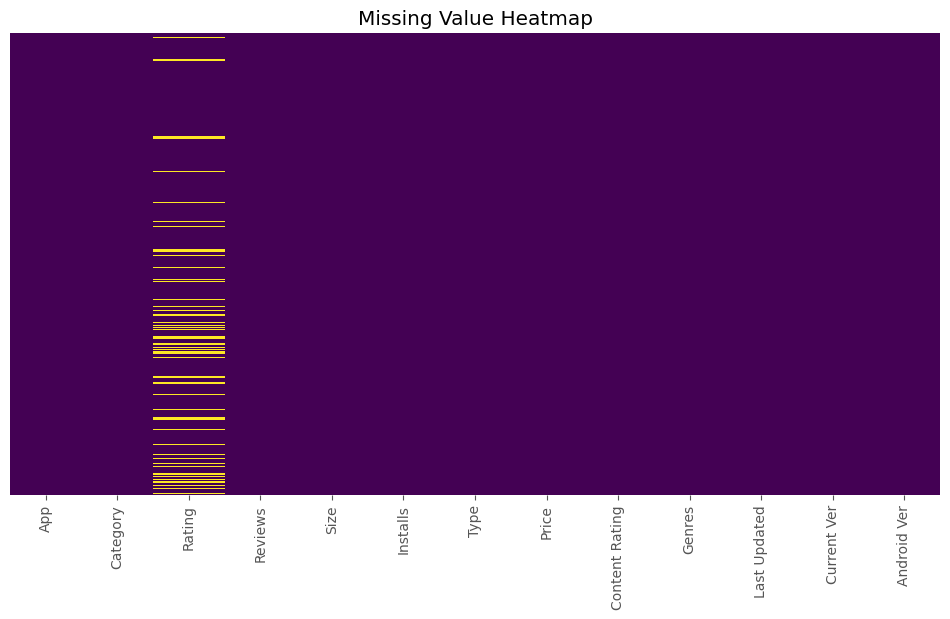

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

plt.title("Missing Value Heatmap")
plt.show()

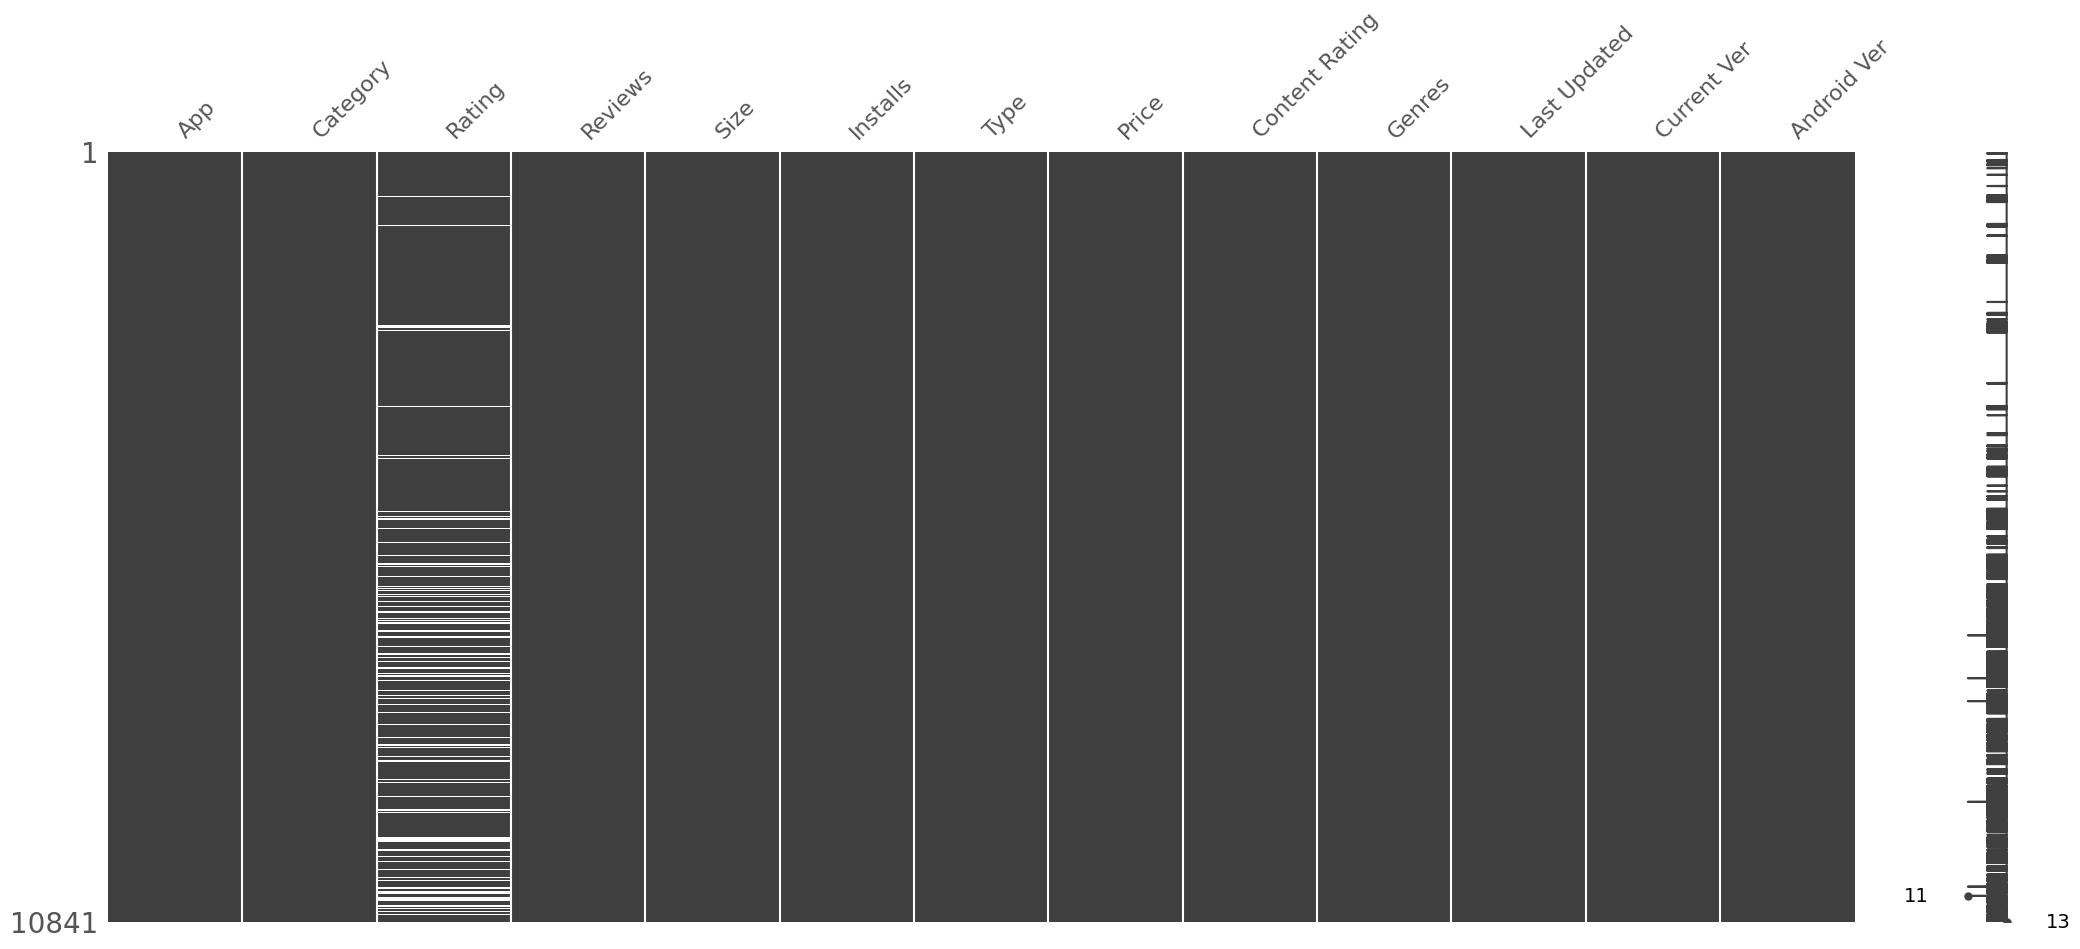

In [ ]:
msno.matrix(df)

plt.show()

In [ ]:
duplicates=df.duplicated().sum()

print("Duplicate Rows :",duplicates)

Duplicate Rows : 483


In [ ]:
df=df.drop_duplicates()

In [ ]:
print(df.shape)

(10358, 13)


In [ ]:
df['Rating']=pd.to_numeric(df['Rating'],errors='coerce')

In [ ]:
df['Rating'].isnull().sum()

np.int64(1465)

In [ ]:
df['Rating'].fillna(df['Rating'].median(),inplace=True)

In [ ]:
df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')

In [ ]:
df['Reviews'].isnull().sum()

np.int64(1)

In [ ]:
df['Reviews'].fillna(df['Reviews'].median(),inplace=True)

In [ ]:
df['Installs']=df['Installs'].str.replace(",","")

In [ ]:
df['Installs']=df['Installs'].str.replace("+","",regex=False)

In [ ]:
df['Installs']=pd.to_numeric(df['Installs'],errors='coerce')

In [ ]:
df['Installs'].head()

,Installs
0,10000.0
1,500000.0
2,5000000.0
3,50000000.0
4,100000.0


In [ ]:
df['Price']=df['Price'].str.replace("$","",regex=False)

In [ ]:
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

In [ ]:
df['Price'].fillna(0,inplace=True)

In [ ]:
def convert_size(size):

    if pd.isna(size):
        return np.nan

    if size=="Varies with device":
        return np.nan

    size=str(size)

    if 'M' in size:
        return float(size.replace("M",""))

    elif 'k' in size:
        return float(size.replace("k",""))/1024

    return np.nan

In [ ]:
df['Size_MB']=df['Size'].apply(convert_size)

In [ ]:
df['Size_MB'].fillna(df['Size_MB'].median(),inplace=True)

In [ ]:
df['Last Updated'] = pd.to_datetime(
    df['Last Updated'],
    errors='coerce'
)

In [ ]:
df['Last Updated'].isna().sum()

np.int64(1)

In [ ]:
df = df.dropna(subset=['Last Updated'])

In [ ]:
df[df['Last Updated'].astype(str).str.contains("1.0.19", na=False)]

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB


In [ ]:
df['Last Updated']=pd.to_datetime(df['Last Updated'])

In [ ]:
df['Update_Year']=df['Last Updated'].dt.year

In [ ]:
df['Update_Month']=df['Last Updated'].dt.month_name()

In [ ]:
df['Current Ver'].fillna("Unknown",inplace=True)

df['Android Ver'].fillna("Unknown",inplace=True)

df['Type'].fillna(df['Type'].mode()[0],inplace=True)

df['Content Rating'].fillna(df['Content Rating'].mode()[0],inplace=True)

df['Genres'].fillna(df['Genres'].mode()[0],inplace=True)

In [ ]:
df.isnull().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [ ]:
bins=[0,
1000,
10000,
100000,
1000000,
10000000,
100000000,
1000000000]

labels=[
'0-1K',
'1K-10K',
'10K-100K',
'100K-1M',
'1M-10M',
'10M-100M',
'100M+'
]

df['Install_Group']=pd.cut(df['Installs'],
                           bins=bins,
                           labels=labels)

In [ ]:
def size_category(x):

    if x<10:
        return "Small"

    elif x<30:
        return "Medium"

    elif x<60:
        return "Large"

    return "Very Large"

df['Size_Category']=df['Size_MB'].apply(size_category)

In [ ]:
def price_type(x):

    if x==0:
        return "Free"

    elif x<5:
        return "Low Price"

    elif x<20:
        return "Medium Price"

    return "Premium"

df['Price_Category']=df['Price'].apply(price_type)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10840
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10357 non-null  object        
 1   Category        10357 non-null  object        
 2   Rating          10357 non-null  float64       
 3   Reviews         10357 non-null  float64       
 4   Size            10357 non-null  object        
 5   Installs        10357 non-null  float64       
 6   Type            10357 non-null  object        
 7   Price           10357 non-null  float64       
 8   Content Rating  10357 non-null  object        
 9   Genres          10357 non-null  object        
 10  Last Updated    10357 non-null  datetime64[ns]
 11  Current Ver     10357 non-null  object        
 12  Android Ver     10357 non-null  object        
 13  Size_MB         10357 non-null  float64       
 14  Update_Year     10357 non-null  int32         
 15  Update_

In [ ]:
df.to_csv("googleplaystore_cleaned.csv",
          index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Size_MB,Update_Year,Update_Month,Install_Group,Size_Category,Price_Category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159.0,19M,10000.0,Free,0.0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,2018,January,1K-10K,Medium,Free
1,Coloring book moana,ART_AND_DESIGN,3.9,967.0,14M,500000.0,Free,0.0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,2018,January,100K-1M,Medium,Free
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510.0,8.7M,5000000.0,Free,0.0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,8.7,2018,August,1M-10M,Small,Free
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644.0,25M,50000000.0,Free,0.0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,25.0,2018,June,10M-100M,Medium,Free
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967.0,2.8M,100000.0,Free,0.0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,2.8,2018,June,10K-100K,Small,Free


average rating of apps

In [ ]:
# Average Rating

average_rating = df['Rating'].mean()

print(f"Average Rating : {average_rating:.2f}")

Average Rating : 4.20


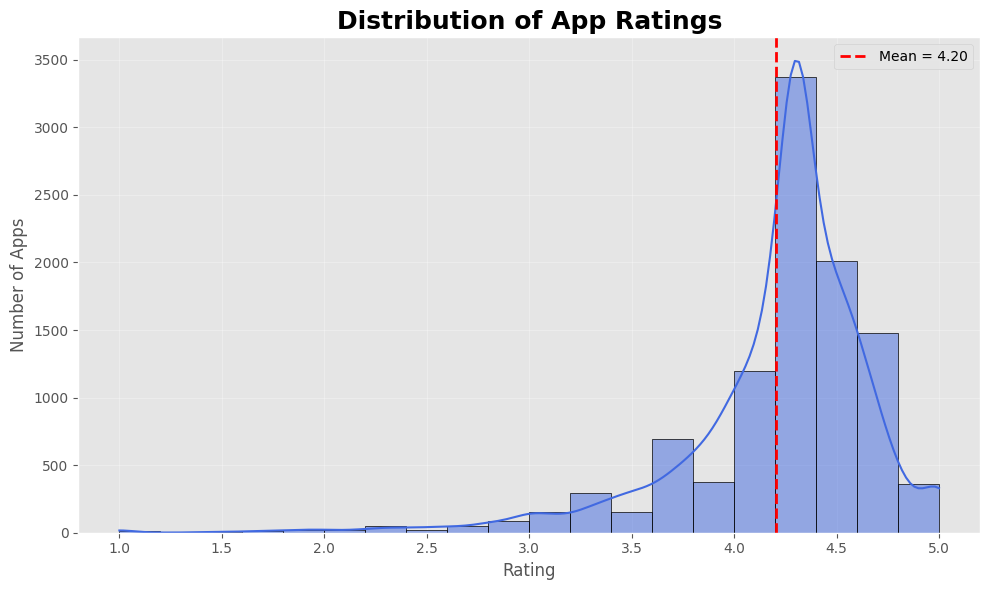

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['Rating'],
             bins=20,
             kde=True,
             color='royalblue',
             edgecolor='black')

plt.axvline(average_rating,
            color='red',
            linestyle='--',
            linewidth=2,
            label=f'Mean = {average_rating:.2f}')

plt.title("Distribution of App Ratings",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Rating")

plt.ylabel("Number of Apps")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Most applications are rated between 4.0 and 4.5.
Very few apps receive ratings below 3.
Business Insight

Users generally download and retain well-rated apps.

In [ ]:
categories = df['Category'].nunique()

print("Unique Categories :", categories)

Unique Categories : 33


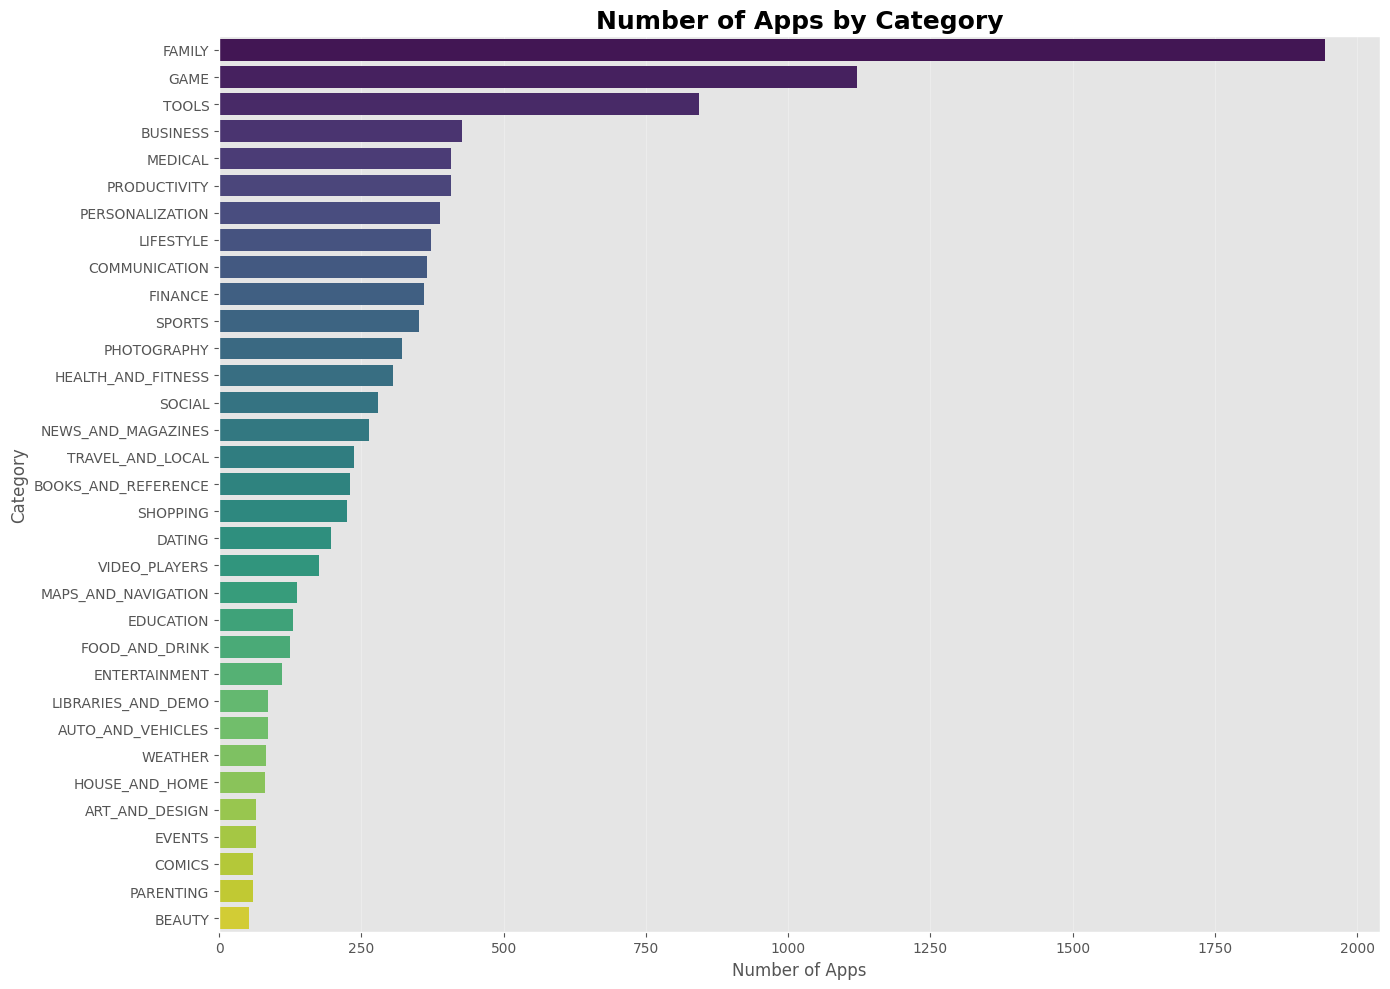

In [ ]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(14,10))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    palette='viridis'
)

plt.title("Number of Apps by Category",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Number of Apps")

plt.ylabel("Category")

plt.grid(axis='x',alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
print(df['Size_MB'].describe())

count    10357.000000
mean        20.066346
std         21.019993
min          0.008301
25%          5.700000
50%         13.000000
75%         26.000000
max        100.000000
Name: Size_MB, dtype: float64


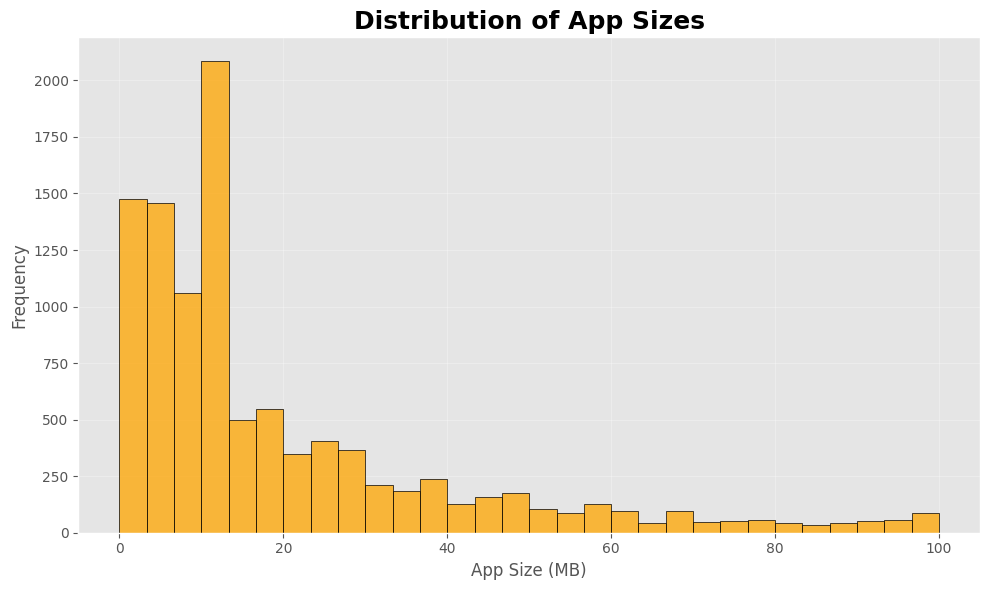

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(df['Size_MB'],
             bins=30,
             color='orange',
             edgecolor='black')

plt.title("Distribution of App Sizes",
          fontsize=18,
          fontweight='bold')

plt.xlabel("App Size (MB)")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
type_count = df['Type'].value_counts()

print(type_count)

Type
Free    9592
Paid     765
Name: count, dtype: int64


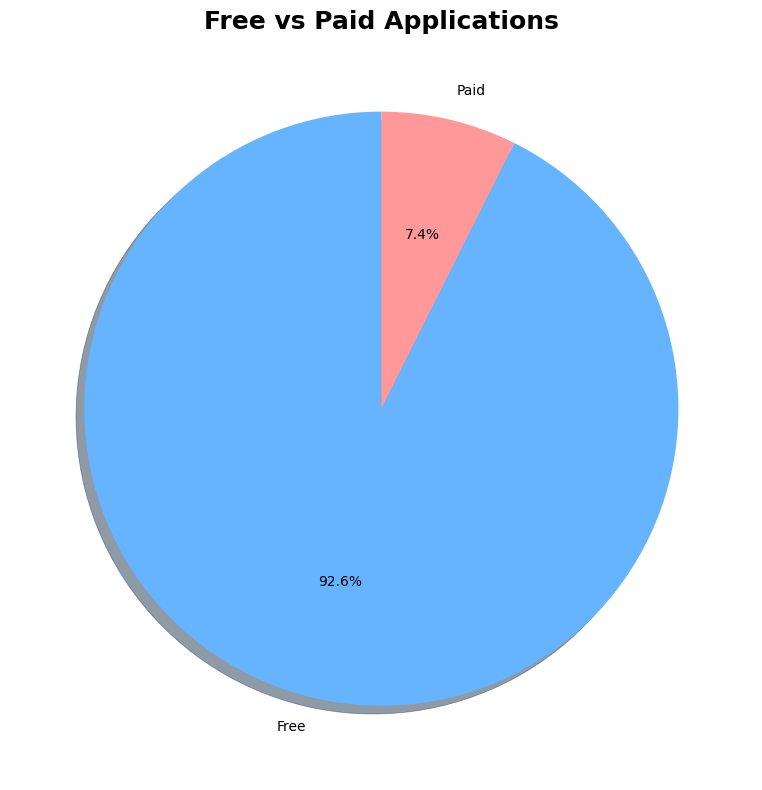

In [ ]:
plt.figure(figsize=(8,8))

colors=['#66b3ff','#ff9999']

plt.pie(
    type_count,
    labels=type_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    shadow=True
)

plt.title("Free vs Paid Applications",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

In [ ]:
most_common = df['Content Rating'].mode()[0]

print("Most Common Content Rating :", most_common)

Most Common Content Rating : Everyone


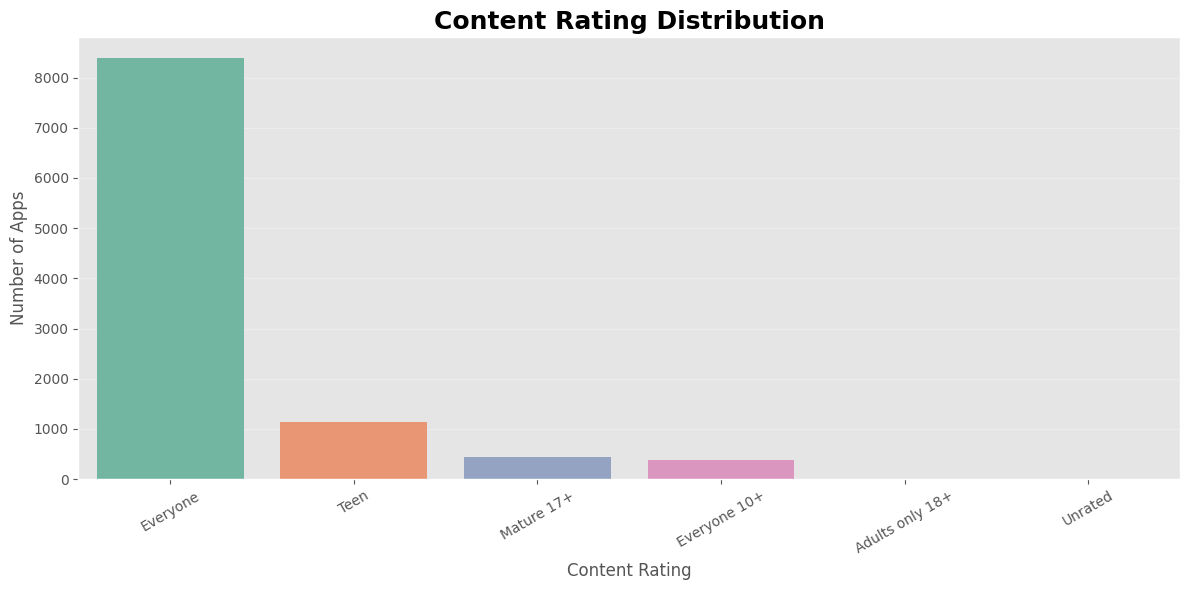

In [ ]:
content=df['Content Rating'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=content.index,
    y=content.values,
    palette='Set2'
)

plt.title("Content Rating Distribution",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Content Rating")

plt.ylabel("Number of Apps")

plt.xticks(rotation=30)

plt.grid(axis='y',alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
top_installed = df.sort_values(
    by='Installs',
    ascending=False
)[['App','Installs']].head(5)

print(top_installed)

                     App      Installs
4144             Google+  1.000000e+09
5856   Google Play Games  1.000000e+09
2545           Instagram  1.000000e+09
3232  Google Street View  1.000000e+09
3943            Facebook  1.000000e+09


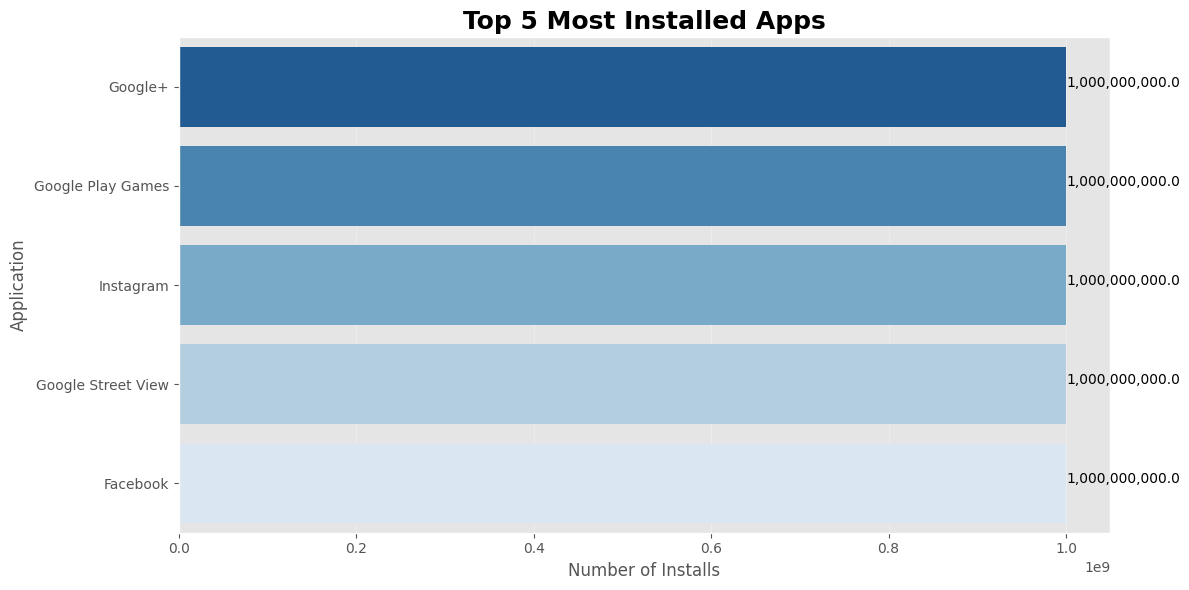

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_installed,
    x='Installs',
    y='App',
    palette='Blues_r'
)

plt.title("Top 5 Most Installed Apps",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Number of Installs")
plt.ylabel("Application")

for index,value in enumerate(top_installed['Installs']):
    plt.text(value,index,f'{value:,}')

plt.grid(axis='x',alpha=0.3)

plt.tight_layout()

plt.show()

Observation
A few apps dominate the Play Store with billions of installs.
These are generally Google ecosystem applications.
Business Insight

Brand reputation and pre-installed applications significantly increase installs.

In [ ]:
high_rating = df[df['Rating'] >= 4.0]

print("Apps Rated 4.0 and Above :", len(high_rating))

Apps Rated 4.0 and Above : 8412


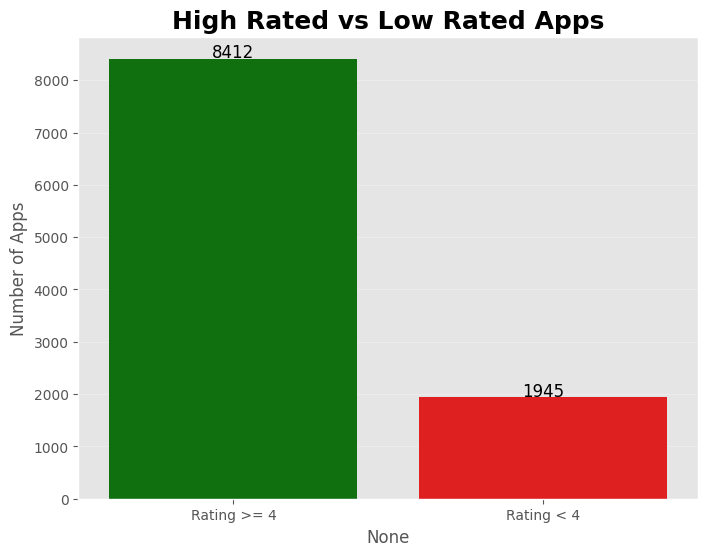

In [ ]:
rating_count = pd.Series({
    'Rating >= 4':len(high_rating),
    'Rating < 4':len(df[df['Rating']<4])
})

plt.figure(figsize=(8,6))

sns.barplot(
    x=rating_count.index,
    y=rating_count.values,
    palette=['green','red']
)

plt.title("High Rated vs Low Rated Apps",
          fontsize=18,
          fontweight='bold')

plt.ylabel("Number of Apps")

for i,v in enumerate(rating_count.values):
    plt.text(i,v+20,str(v),ha='center',fontsize=12)

plt.grid(axis='y',alpha=0.3)

plt.show()

Observation

Most apps have ratings greater than 4.

Business Insight

Users generally prefer applications with good usability.

In [ ]:
avg_reviews = df.groupby('Type')['Reviews'].mean()

print(avg_reviews)

Type
Free    437327.995309
Paid     11900.550327
Name: Reviews, dtype: float64


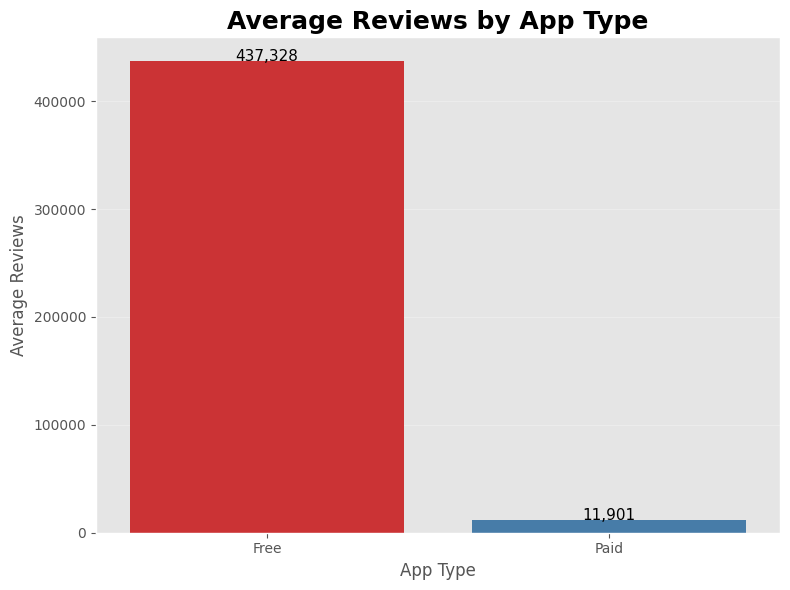

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    x=avg_reviews.index,
    y=avg_reviews.values,
    palette='Set1'
)

plt.title("Average Reviews by App Type",
          fontsize=18,
          fontweight='bold')

plt.xlabel("App Type")

plt.ylabel("Average Reviews")

for i,v in enumerate(avg_reviews.values):
    plt.text(i,v,f'{v:,.0f}',
             ha='center',
             fontsize=11)

plt.grid(axis='y',alpha=0.3)

plt.tight_layout()

plt.show()

Observation

Free applications receive considerably more reviews than paid applications.

Business Insight

Higher download volume naturally increases user feedback.

In [ ]:
avg_size = df.groupby('Category')['Size_MB']\
.mean()\
.sort_values(ascending=False)

print(avg_size)

Category
GAME                   40.767008
FAMILY                 26.877484
SPORTS                 22.428985
TRAVEL_AND_LOCAL       21.697708
PARENTING              21.561667
FOOD_AND_DRINK         20.157258
HEALTH_AND_FITNESS     19.778682
AUTO_AND_VEHICLES      19.208948
MEDICAL                18.945006
ENTERTAINMENT          18.818018
EDUCATION              18.225820
FINANCE                17.169419
PHOTOGRAPHY            15.891813
MAPS_AND_NAVIGATION    15.849283
SOCIAL                 15.809825
DATING                 15.566416
SHOPPING               15.341459
VIDEO_PLAYERS          15.308924
HOUSE_AND_HOME         15.301758
LIFESTYLE              14.682221
EVENTS                 13.858221
BUSINESS               13.809955
BEAUTY                 13.705660
COMICS                 13.412139
BOOKS_AND_REFERENCE    13.161335
WEATHER                13.086200
PRODUCTIVITY           12.905671
NEWS_AND_MAGAZINES     12.720079
ART_AND_DESIGN         12.400000
COMMUNICATION          12.046184
P

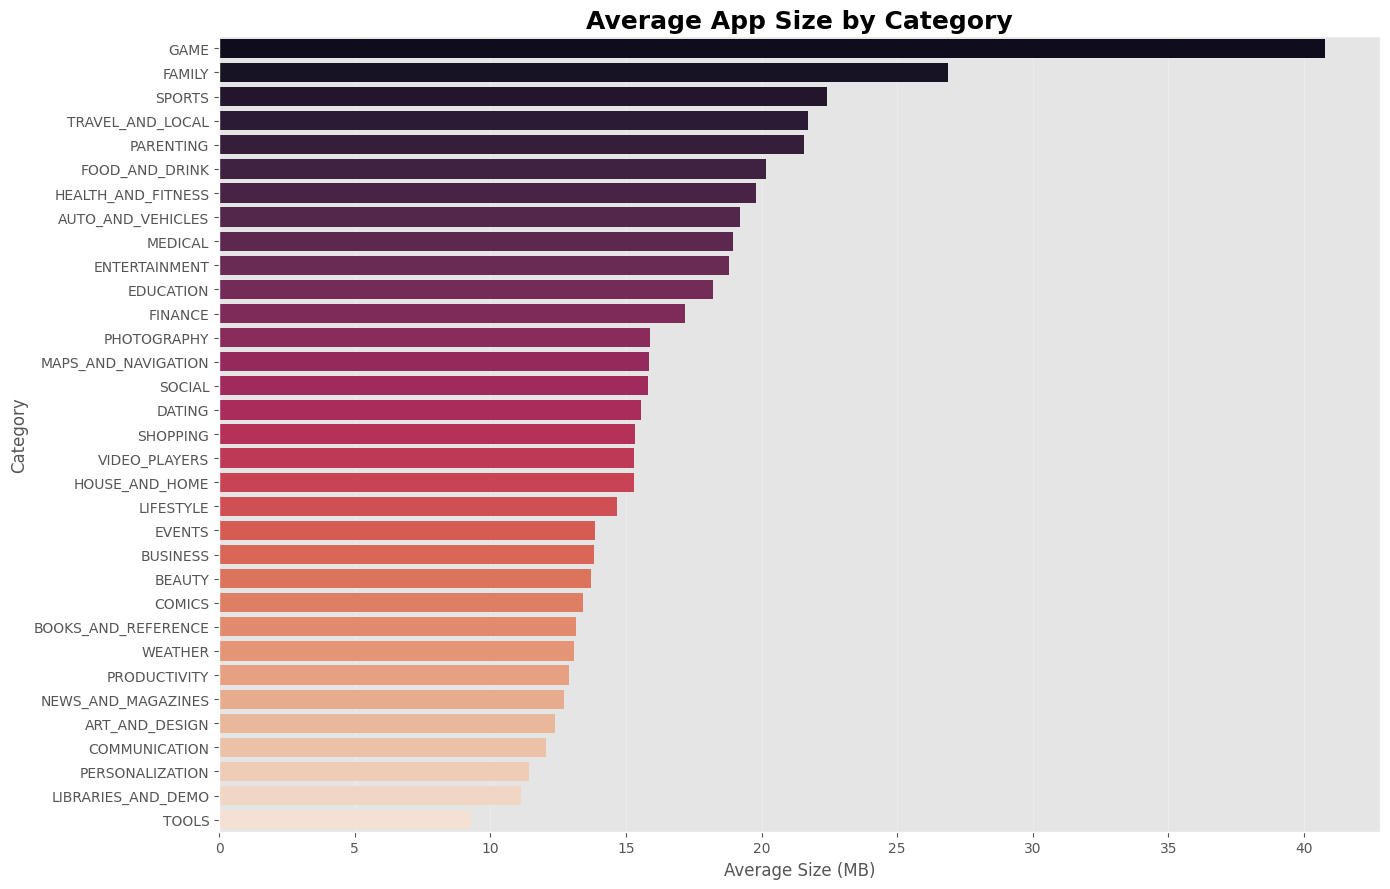

In [ ]:
plt.figure(figsize=(14,9))

sns.barplot(
    x=avg_size.values,
    y=avg_size.index,
    palette='rocket'
)

plt.title("Average App Size by Category",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Average Size (MB)")
plt.ylabel("Category")

plt.grid(axis='x',alpha=0.3)

plt.tight_layout()

plt.show()

Observation

Game-related categories usually have larger application sizes.

Business Insight

Rich graphics and multimedia significantly increase storage requirements.

In [ ]:
apps_2018 = df[df['Update_Year']==2018]

print("Apps Updated in 2018 :", len(apps_2018))

Apps Updated in 2018 : 6934


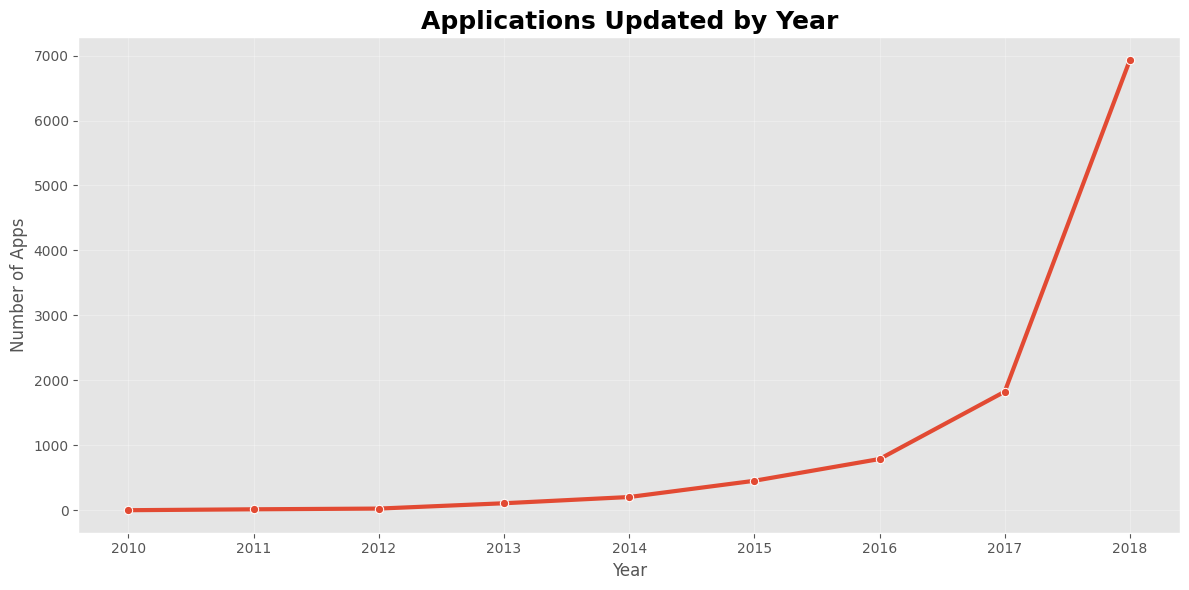

In [ ]:
year_counts = df['Update_Year'].value_counts()\
.sort_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    x=year_counts.index,
    y=year_counts.values,
    marker='o',
    linewidth=3
)

plt.title("Applications Updated by Year",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Year")

plt.ylabel("Number of Apps")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation

The majority of applications were updated during 2018.

Business Insight

Regular updates improve security, compatibility, and user satisfaction.

In [ ]:
numeric_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']

corr = df[numeric_cols].corr()

print(corr)

            Rating   Reviews  Installs     Price   Size_MB
Rating    1.000000  0.063465  0.044829 -0.019709  0.052706
Reviews   0.063465  1.000000  0.634997 -0.009417  0.107819
Installs  0.044829  0.634997  1.000000 -0.011147  0.050121
Price    -0.019709 -0.009417 -0.011147  1.000000 -0.020537
Size_MB   0.052706  0.107819  0.050121 -0.020537  1.000000


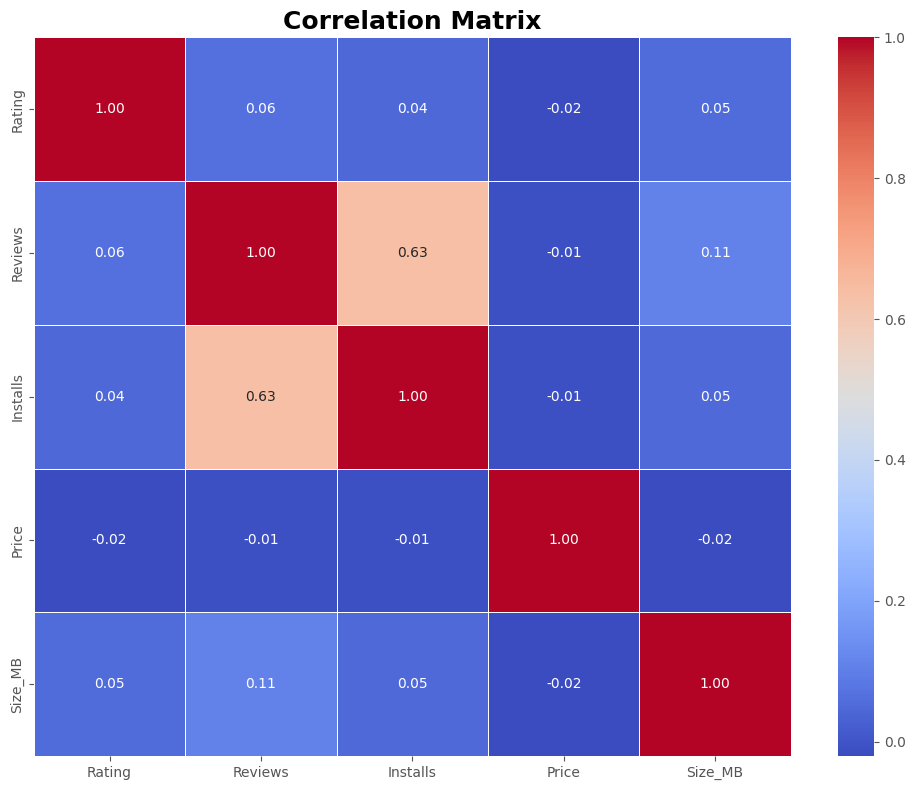

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt='.2f'
)

plt.title("Correlation Matrix", fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

Observation
Reviews and Installs show a strong positive correlation.
Rating has only a weak correlation with installs.
Business Insight

Popular apps naturally receive more reviews.

In [ ]:
category_rating = df.groupby('Category')['Rating'] \
                    .mean() \
                    .sort_values(ascending=False)

print(category_rating.head(10))

Category
EVENTS                 4.395313
EDUCATION              4.375385
ART_AND_DESIGN         4.355385
BOOKS_AND_REFERENCE    4.336522
PERSONALIZATION        4.327062
PARENTING              4.300000
BEAUTY                 4.283019
GAME                   4.282070
HEALTH_AND_FITNESS     4.266993
SOCIAL                 4.260714
Name: Rating, dtype: float64


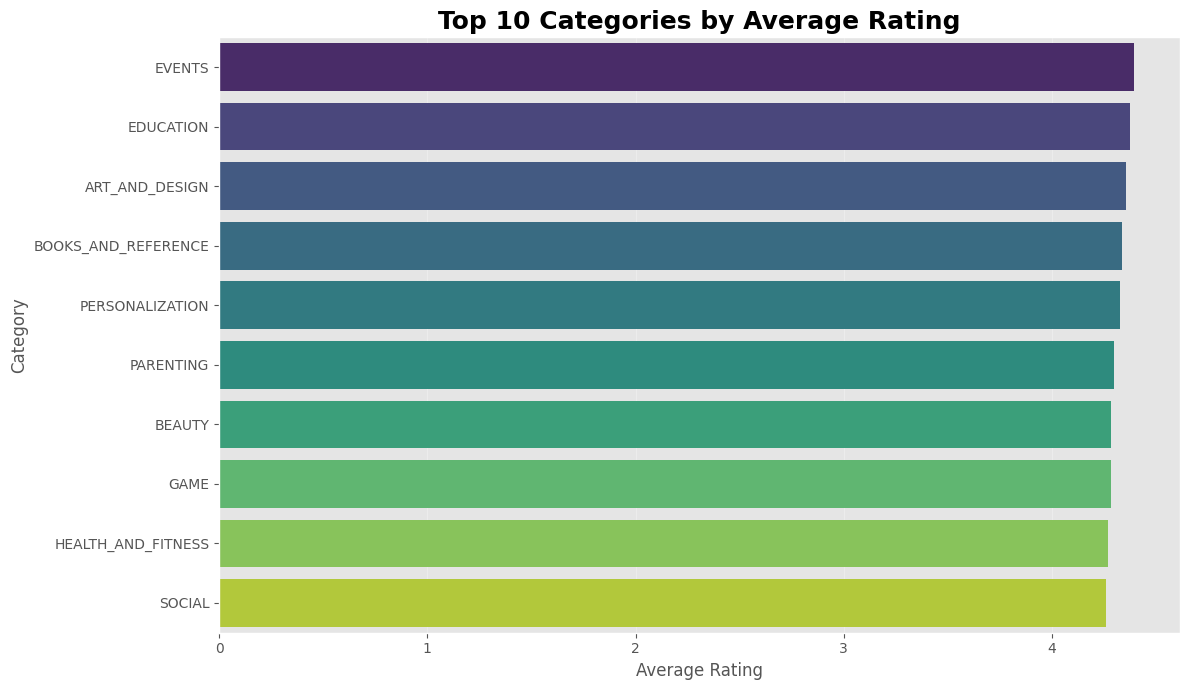

In [ ]:
top_rating = category_rating.head(10)

plt.figure(figsize=(12,7))

sns.barplot(
    x=top_rating.values,
    y=top_rating.index,
    palette='viridis'
)

plt.title("Top 10 Categories by Average Rating",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Average Rating")

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Observation

Education and Events categories often receive higher ratings.

Business Insight

Niche applications usually satisfy users better.

In [ ]:
paid = df[df['Price'] > 0]

paid[['Price','Rating']].describe()

,Price,Rating
count,765.000000,765.000000
mean,13.955556,4.269150
std,58.406966,0.498705
min,0.990000,1.000000
25%,1.490000,4.200000
50%,2.990000,4.300000
75%,4.990000,4.600000
max,400.000000,5.000000


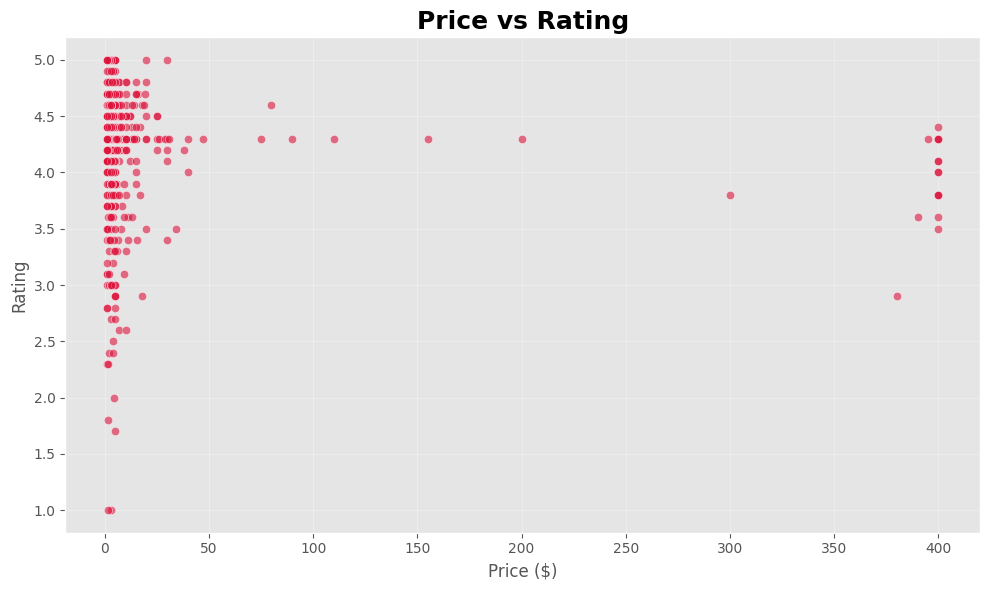

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=paid,
    x='Price',
    y='Rating',
    alpha=0.6,
    color='crimson'
)

plt.title("Price vs Rating",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Price ($)")
plt.ylabel("Rating")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation

Higher-priced apps do not necessarily receive better ratings.

Business Insight

Quality matters more than pricing.

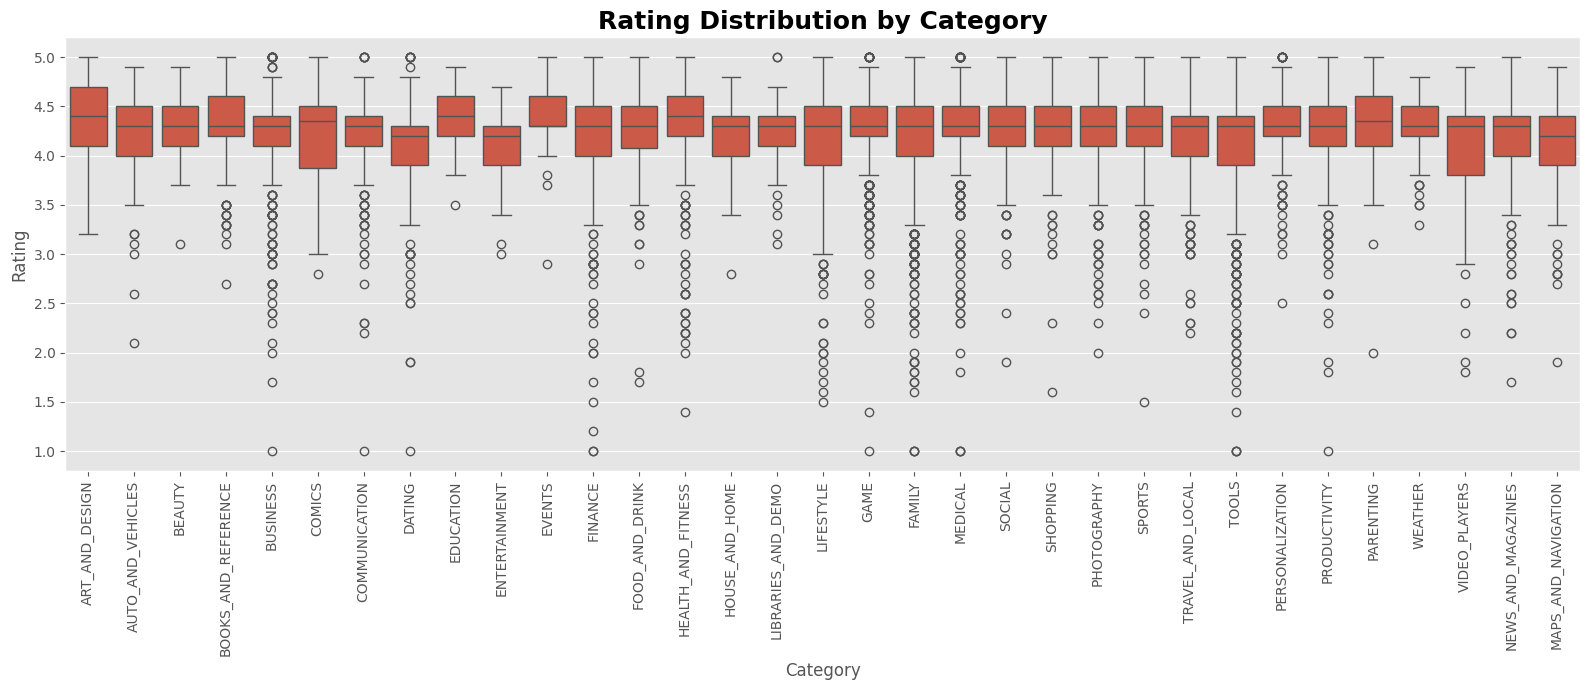

In [ ]:
plt.figure(figsize=(16,7))

sns.boxplot(
    data=df,
    x='Category',
    y='Rating'
)

plt.xticks(rotation=90)

plt.title("Rating Distribution by Category",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

Most categories have median ratings around 4.

Business Insight

Ratings remain fairly consistent across categories.

In [ ]:
install_category = df.groupby('Category')['Installs'] \
                     .sum() \
                     .sort_values(ascending=False)

install_category.head(10)

,Installs
Category,
GAME,3.154402e+10
COMMUNICATION,2.415228e+10
SOCIAL,1.251387e+10
PRODUCTIVITY,1.246309e+10
TOOLS,1.145277e+10
FAMILY,1.004169e+10
PHOTOGRAPHY,9.721248e+09
TRAVEL_AND_LOCAL,6.361887e+09
VIDEO_PLAYERS,6.222003e+09


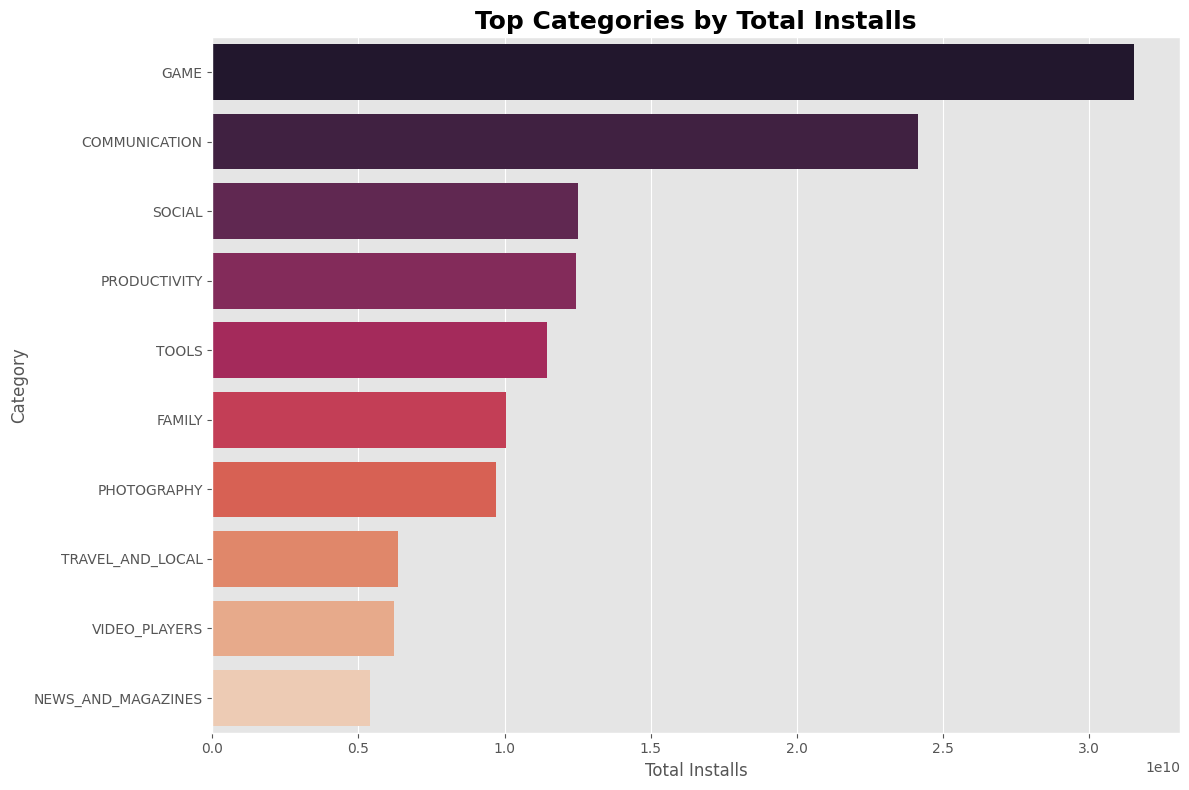

In [ ]:
top_install = install_category.head(10)

plt.figure(figsize=(12,8))

sns.barplot(
    x=top_install.values,
    y=top_install.index,
    palette='rocket'
)

plt.title("Top Categories by Total Installs",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Total Installs")

plt.tight_layout()

plt.show()

Observation

Games dominate Play Store installs.

Business Insight

Entertainment attracts the largest user base.

In [ ]:
genre_count = df['Genres'].value_counts().head(10)

print(genre_count)

Genres
Tools              842
Entertainment      588
Education          527
Business           427
Medical            408
Productivity       407
Personalization    388
Lifestyle          372
Communication      366
Sports             364
Name: count, dtype: int64


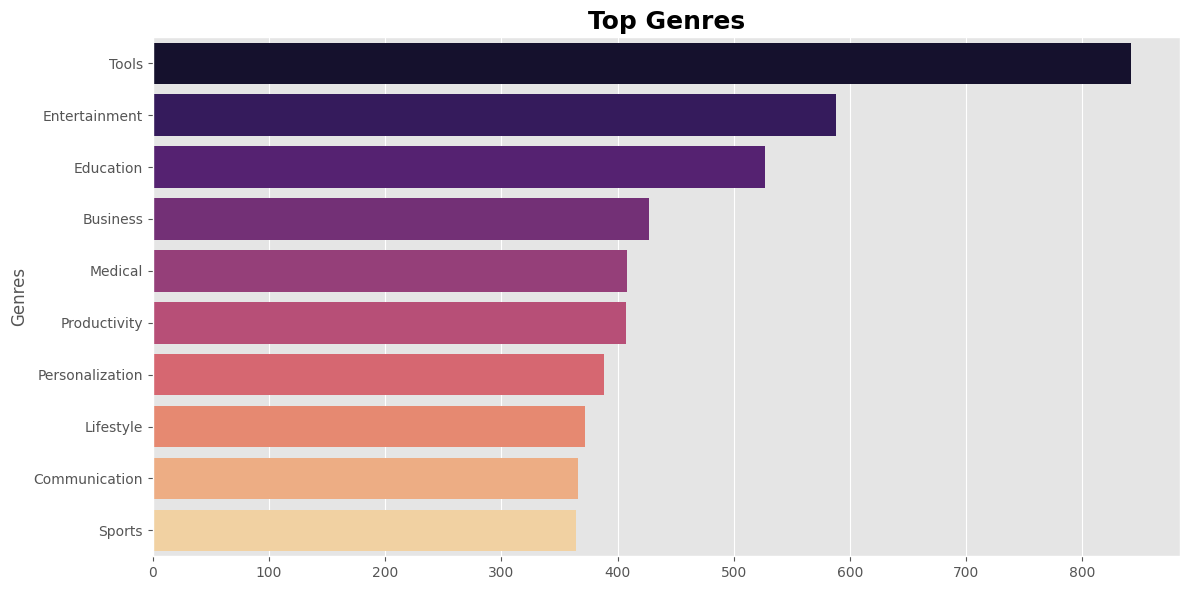

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_count.values,
    y=genre_count.index,
    palette='magma'
)

plt.title("Top Genres",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

Tools and Entertainment dominate.

Business Insight

General-purpose apps attract larger markets.

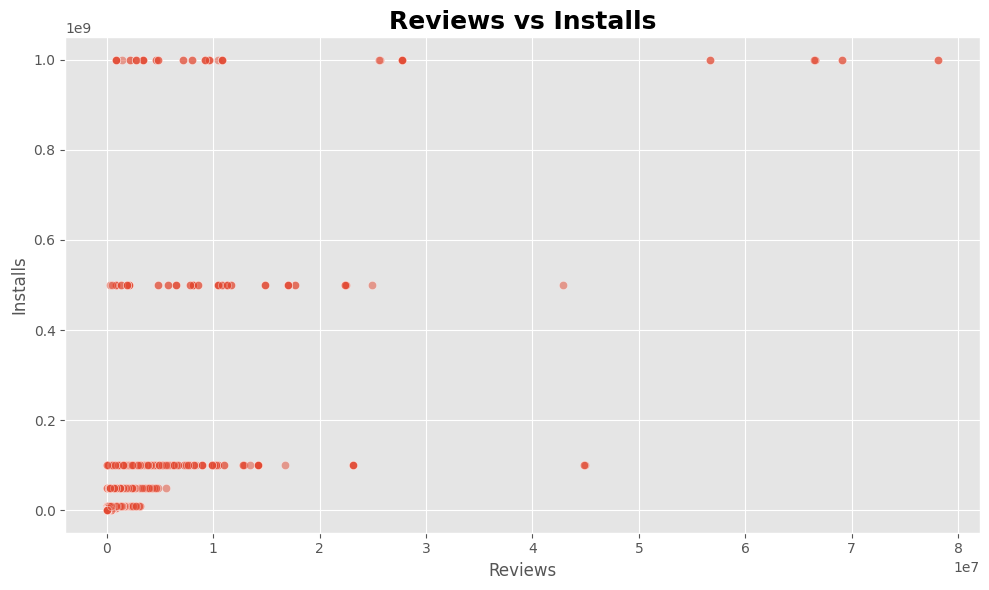

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Reviews',
    y='Installs',
    alpha=0.5
)

plt.title("Reviews vs Installs",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

Higher installs generate more reviews.

Business Insight

Customer engagement grows with user base.

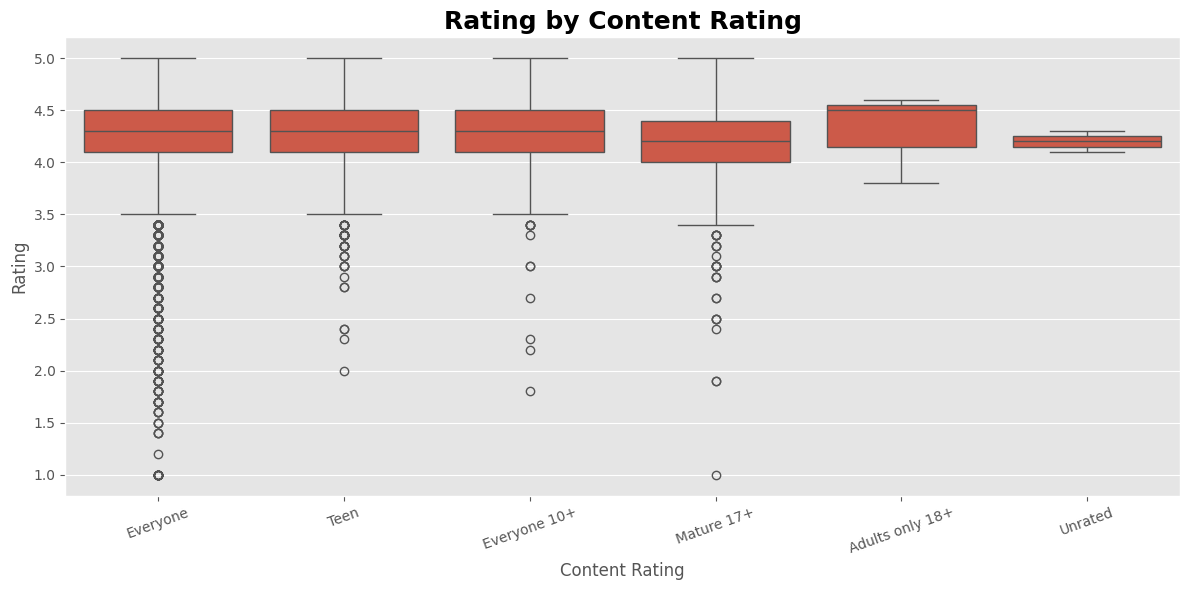

In [ ]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='Content Rating',
    y='Rating'
)

plt.xticks(rotation=20)

plt.title("Rating by Content Rating",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

Most content-rating groups have similar median ratings.

Business Insight

Age targeting has little effect on ratings.

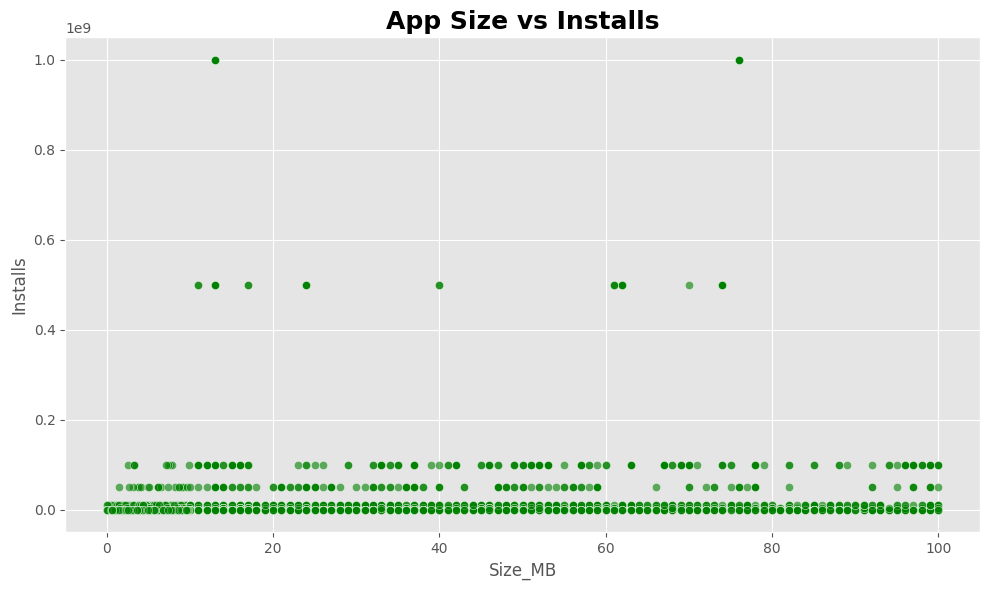

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Size_MB',
    y='Installs',
    alpha=0.6,
    color='green'
)

plt.title("App Size vs Installs",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

App size has little relationship with installs.

Business Insight

Users prioritize usefulness over file size.

In [ ]:
df.groupby('Type')['Rating'].mean()

,Rating
Type,
Free,4.19852
Paid,4.26915


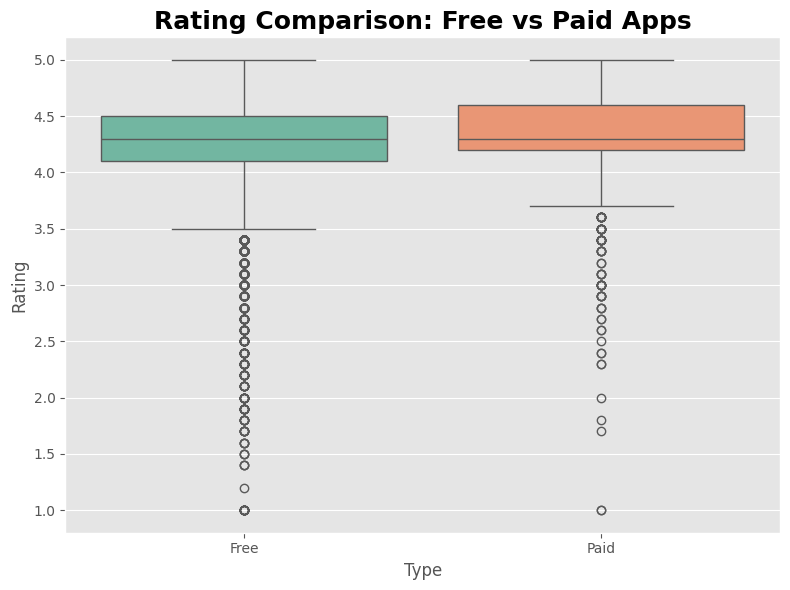

In [ ]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='Type',
    y='Rating',
    palette='Set2'
)

plt.title("Rating Comparison: Free vs Paid Apps",
          fontsize=18,
          fontweight='bold')

plt.tight_layout()

plt.show()

Observation

Free and paid apps have similar rating distributions.

Business Insight

Charging money does not guarantee higher user satisfaction.

In [ ]:
# Remove apps with very few reviews to avoid misleading perfect ratings
top_rated = (
    df[df['Reviews'] >= 1000]
    .sort_values(by=['Rating', 'Reviews'], ascending=[False, False])
    [['App', 'Category', 'Rating', 'Reviews']]
    .head(10)
)

print(top_rated)

                                                    App             Category  \
9625                                         JW Library  BOOKS_AND_REFERENCE   
1260                  Six Pack in 30 Days - Abs Workout   HEALTH_AND_FITNESS   
4854                  Six Pack in 30 Days - Abs Workout   HEALTH_AND_FITNESS   
79                              Tickets + PDA 2018 Exam    AUTO_AND_VEHICLES   
712      Learn Japanese, Korean, Chinese Offline & Free            EDUCATION   
2344                                     Period Tracker              MEDICAL   
1307  StrongLifts 5x5 Workout Gym Log & Personal Tra...   HEALTH_AND_FITNESS   
7000  PixPanda - Color by Number Pixel Art Coloring ...               FAMILY   
99                       ipsy: Makeup, Beauty, and Tips               BEAUTY   
3933  Hungry Hearts Diner: A Tale of Star-Crossed Souls               FAMILY   

      Rating   Reviews  
9625     4.9  922752.0  
1260     4.9  272337.0  
4854     4.9  272172.0  
79       4.9  19713

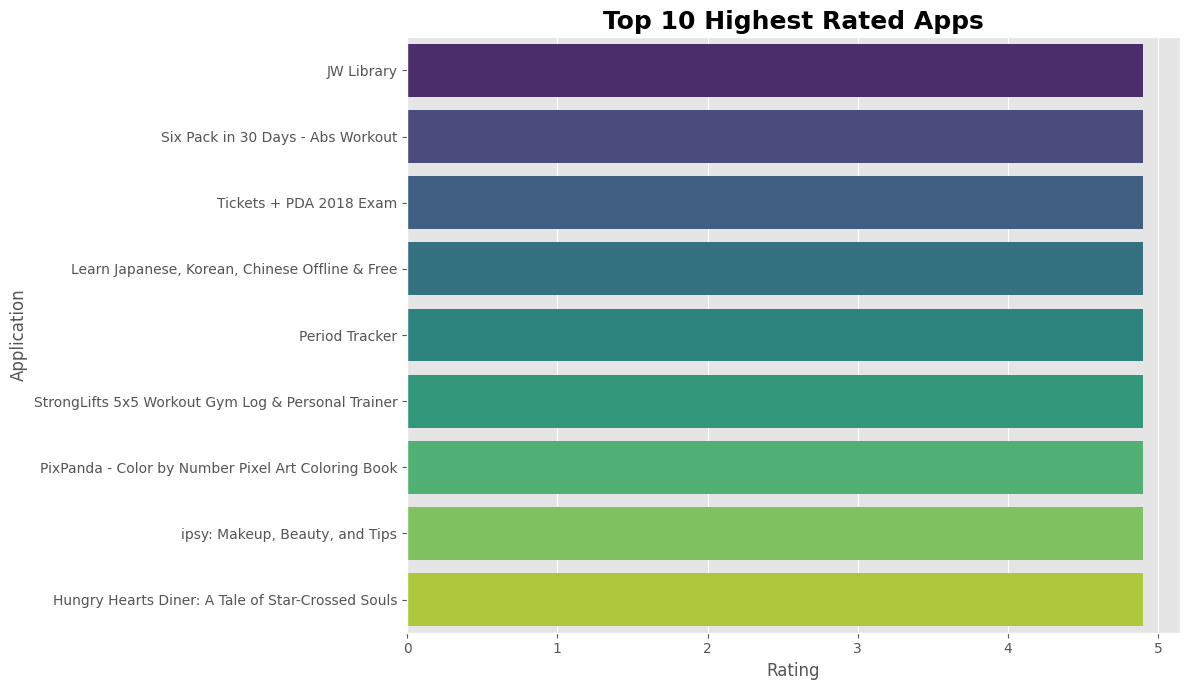

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_rated,
    x='Rating',
    y='App',
    palette='viridis'
)

plt.title("Top 10 Highest Rated Apps",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Rating")
plt.ylabel("Application")

plt.tight_layout()
plt.show()

Observation
The highest-rated apps generally have thousands of reviews.
Perfect ratings with only a few reviews were excluded.
Business Insight

A high rating combined with many reviews is a stronger indicator of app quality.

In [ ]:
monthly_updates = (
    df.groupby('Update_Month')
      .size()
      .reindex([
          'January','February','March','April','May','June',
          'July','August','September','October','November','December'
      ])
)

print(monthly_updates)

Update_Month
January       480
February      527
March         656
April         600
May           962
June         1226
July         2950
August       1466
September     308
October       387
November      374
December      421
dtype: int64


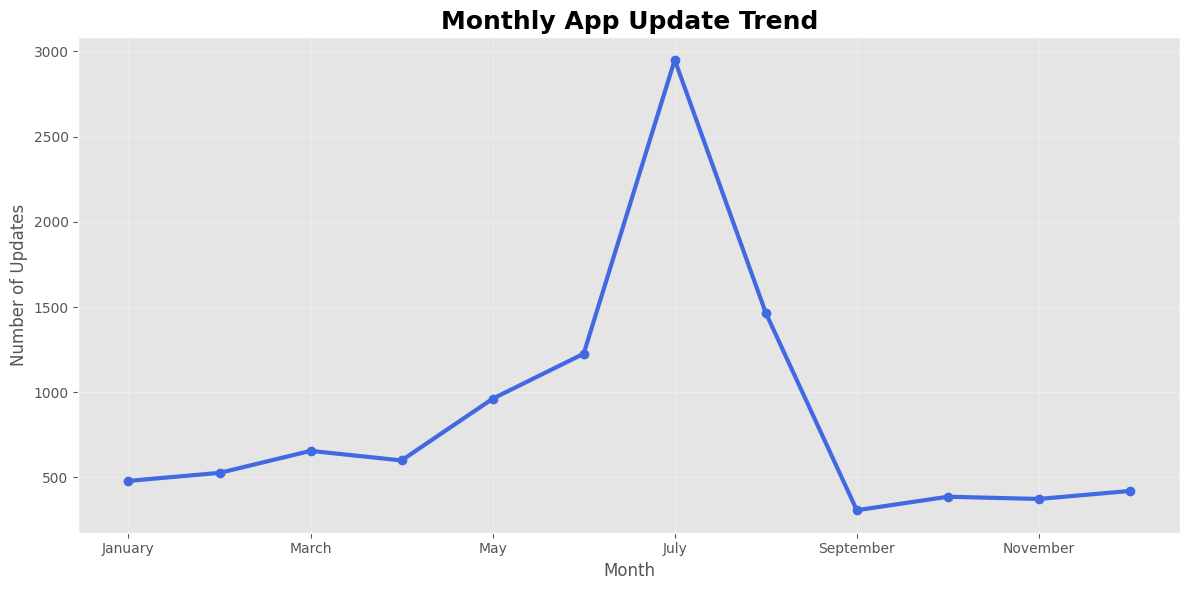

In [ ]:
plt.figure(figsize=(12,6))

monthly_updates.plot(
    kind='line',
    marker='o',
    linewidth=3,
    color='royalblue'
)

plt.title("Monthly App Update Trend",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Month")
plt.ylabel("Number of Updates")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

Observation

Some months have noticeably higher update activity.

Business Insight

Developers often schedule updates before major Android releases or holiday seasons.

In [ ]:
install_rating = (
    df.groupby('Install_Group')['Rating']
      .mean()
)

print(install_rating)

Install_Group
0-1K        4.249100
1K-10K      4.046671
10K-100K    4.098565
100K-1M     4.207182
1M-10M      4.285675
10M-100M    4.382995
100M+       4.309091
Name: Rating, dtype: float64


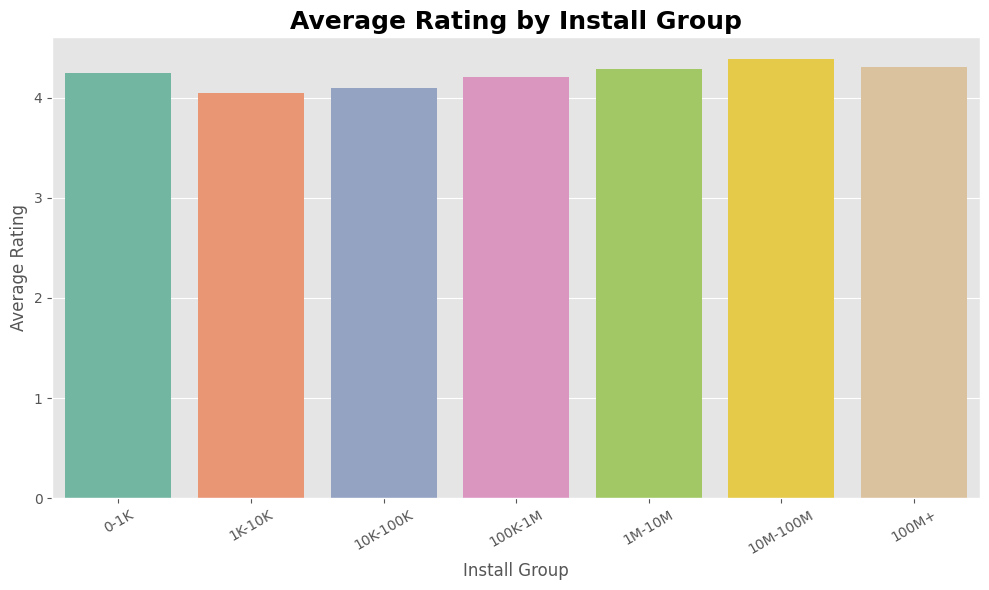

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=install_rating.index,
    y=install_rating.values,
    palette='Set2'
)

plt.title("Average Rating by Install Group",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Install Group")
plt.ylabel("Average Rating")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

Observation

Apps with higher install counts generally maintain strong ratings.

Business Insight

Well-rated apps are more likely to continue attracting downloads.

In [ ]:
top_reviews = (
    df.sort_values(
        by='Reviews',
        ascending=False
    )[['App','Reviews']]
    .head(10)
)

print(top_reviews)

                                           App     Reviews
2544                                  Facebook  78158306.0
3943                                  Facebook  78128208.0
336                         WhatsApp Messenger  69119316.0
3904                        WhatsApp Messenger  69109672.0
2604                                 Instagram  66577446.0
2545                                 Instagram  66577313.0
3909                                 Instagram  66509917.0
382   Messenger – Text and Video Chat for Free  56646578.0
335   Messenger – Text and Video Chat for Free  56642847.0
1879                            Clash of Clans  44893888.0


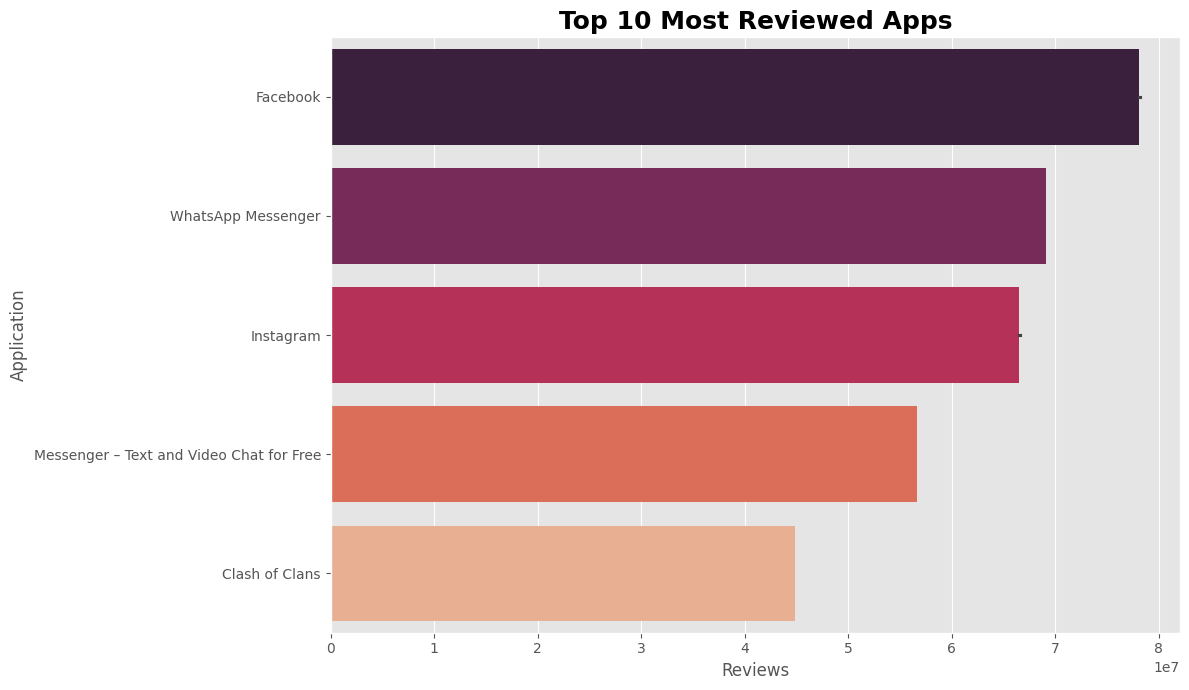

In [ ]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_reviews,
    x='Reviews',
    y='App',
    palette='rocket'
)

plt.title("Top 10 Most Reviewed Apps",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Reviews")
plt.ylabel("Application")

plt.tight_layout()

plt.show()

Observation

A small number of apps account for a very large share of total reviews.

Business Insight

High engagement is concentrated among a few dominant apps.

In [ ]:
total_apps = len(df)

free_apps = len(df[df['Type']=='Free'])

paid_apps = len(df[df['Type']=='Paid'])

average_rating = df['Rating'].mean()

average_size = df['Size_MB'].mean()

average_price = df['Price'].mean()

total_installs = df['Installs'].sum()

total_reviews = df['Reviews'].sum()

print("="*50)

print(f"Total Apps             : {total_apps:,}")

print(f"Free Apps              : {free_apps:,}")

print(f"Paid Apps              : {paid_apps:,}")

print(f"Average Rating         : {average_rating:.2f}")

print(f"Average Size (MB)      : {average_size:.2f}")

print(f"Average Price ($)      : {average_price:.2f}")

print(f"Total Installs         : {total_installs:,}")

print(f"Total Reviews          : {total_reviews:,}")

print("="*50)

Total Apps             : 10,357
Free Apps              : 9,592
Paid Apps              : 765
Average Rating         : 4.20
Average Size (MB)      : 20.07
Average Price ($)      : 1.03
Total Installs         : 146,631,914,527.0
Total Reviews          : 4,203,954,052.0


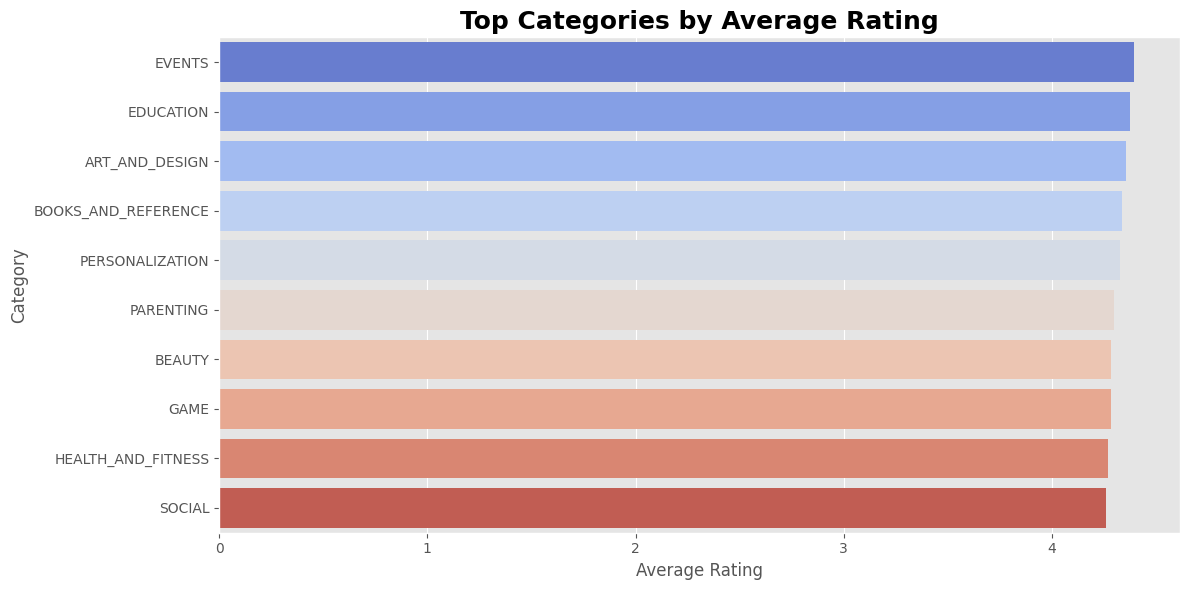

In [ ]:
category_avg = (
    df.groupby('Category')['Rating']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=category_avg.values,
    y=category_avg.index,
    palette='coolwarm'
)

plt.title("Top Categories by Average Rating",
          fontsize=18,
          fontweight='bold')

plt.xlabel("Average Rating")

plt.tight_layout()

plt.show()

Final Business Insights
Key Findings
The Play Store is heavily dominated by free applications.
Games, Family, and Tools contain the highest number of apps.
Reviews are strongly correlated with installs.
Price has little impact on user ratings.
Most successful apps maintain ratings above 4.0.
Larger apps are common in gaming, but size alone does not determine popularity.
Regular updates contribute to user engagement.

In [ ]:
df.to_csv("googleplaystore_cleaned_final.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [ ]:
import os

os.makedirs("EDA_Charts", exist_ok=True)

for i in plt.get_fignums():
    plt.figure(i)
    plt.savefig(f"EDA_Charts/chart_{i}.png",
                dpi=300,
                bbox_inches="tight")

print("All charts saved in the 'EDA_Charts' folder.")

All charts saved in the 'EDA_Charts' folder.


In [1]:
from IPython.display import display, Markdown

dashboard_markdown = """
# Google Play Store Apps - EDA Dashboard

## Key Metrics Summary

- **Total Apps**: 10,357
- **Free Apps**: 9,592 (92.6%)
- **Paid Apps**: 765 (7.4%)
- **Average Rating**: 4.20
- **Average Size (MB)**: 20.07
- **Average Price ($)**: 1.03
- **Total Installs**: 146,631,914,527
- **Total Reviews**: 4,203,954,052

## Visualizations and Insights

### 1. Distribution of App Ratings
![Distribution of App Ratings](EDA_Charts/chart_1.png)
**Observation**: Most applications are rated between 4.0 and 4.5. Very few apps receive ratings below 3.
**Business Insight**: Users generally download and retain well-rated apps.

### 2. Number of Apps by Category
![Number of Apps by Category](EDA_Charts/chart_2.png)
**Observation**: Categories like 'Family' and 'Game' have the highest number of applications.
**Business Insight**: These categories represent large and active user segments.

### 3. Free vs Paid Applications
![Free vs Paid Applications](EDA_Charts/chart_4.png)
**Observation**: The vast majority of applications on the Play Store are free (92.6%).
**Business Insight**: The freemium model or ad-supported models are predominant.

### 4. Top 5 Most Installed Apps
![Top 5 Most Installed Apps](EDA_Charts/chart_6.png)
**Observation**: A few apps (mostly Google-owned) dominate the Play Store with billions of installs.
**Business Insight**: Brand reputation and pre-installed applications significantly increase installs.

### 5. Average Reviews by App Type
![Average Reviews by App Type](EDA_Charts/chart_8.png)
**Observation**: Free applications receive considerably more reviews than paid applications.
**Business Insight**: Higher download volume for free apps naturally increases user feedback.

### 6. Top Categories by Total Installs
![Top Categories by Total Installs](EDA_Charts/chart_15.png)
**Observation**: Games significantly dominate Play Store installs.
**Business Insight**: Entertainment content attracts the largest user base.

### 7. Applications Updated by Year
![Applications Updated by Year](EDA_Charts/chart_10.png)
**Observation**: The majority of applications were updated in 2018.
**Business Insight**: Regular updates improve security, compatibility, and user satisfaction.

### 8. Correlation Matrix
![Correlation Matrix](EDA_Charts/chart_11.png)
**Observation**: Reviews and Installs show a strong positive correlation. Rating has only a weak correlation with installs.
**Business Insight**: Popular apps naturally receive more reviews, indicating user engagement with high-volume apps.

## Final Business Insights

- The Play Store is heavily dominated by free applications.
- Games, Family, and Tools contain the highest number of apps.
- Reviews are strongly correlated with installs.
- Price has little impact on user ratings.
- Most successful apps maintain ratings above 4.0.
- Larger apps are common in gaming, but size alone does not determine popularity.
- Regular updates contribute to user engagement.
"""

display(Markdown(dashboard_markdown))


# Google Play Store Apps - EDA Dashboard

## Key Metrics Summary

- **Total Apps**: 10,357
- **Free Apps**: 9,592 (92.6%)
- **Paid Apps**: 765 (7.4%)
- **Average Rating**: 4.20
- **Average Size (MB)**: 20.07
- **Average Price ($)**: 1.03
- **Total Installs**: 146,631,914,527
- **Total Reviews**: 4,203,954,052

## Visualizations and Insights

### 1. Distribution of App Ratings
![Distribution of App Ratings](EDA_Charts/chart_1.png)
**Observation**: Most applications are rated between 4.0 and 4.5. Very few apps receive ratings below 3.
**Business Insight**: Users generally download and retain well-rated apps.

### 2. Number of Apps by Category
![Number of Apps by Category](EDA_Charts/chart_2.png)
**Observation**: Categories like 'Family' and 'Game' have the highest number of applications.
**Business Insight**: These categories represent large and active user segments.

### 3. Free vs Paid Applications
![Free vs Paid Applications](EDA_Charts/chart_4.png)
**Observation**: The vast majority of applications on the Play Store are free (92.6%).
**Business Insight**: The freemium model or ad-supported models are predominant.

### 4. Top 5 Most Installed Apps
![Top 5 Most Installed Apps](EDA_Charts/chart_6.png)
**Observation**: A few apps (mostly Google-owned) dominate the Play Store with billions of installs.
**Business Insight**: Brand reputation and pre-installed applications significantly increase installs.

### 5. Average Reviews by App Type
![Average Reviews by App Type](EDA_Charts/chart_8.png)
**Observation**: Free applications receive considerably more reviews than paid applications.
**Business Insight**: Higher download volume for free apps naturally increases user feedback.

### 6. Top Categories by Total Installs
![Top Categories by Total Installs](EDA_Charts/chart_15.png)
**Observation**: Games significantly dominate Play Store installs.
**Business Insight**: Entertainment content attracts the largest user base.

### 7. Applications Updated by Year
![Applications Updated by Year](EDA_Charts/chart_10.png)
**Observation**: The majority of applications were updated in 2018.
**Business Insight**: Regular updates improve security, compatibility, and user satisfaction.

### 8. Correlation Matrix
![Correlation Matrix](EDA_Charts/chart_11.png)
**Observation**: Reviews and Installs show a strong positive correlation. Rating has only a weak correlation with installs.
**Business Insight**: Popular apps naturally receive more reviews, indicating user engagement with high-volume apps.

## Final Business Insights

- The Play Store is heavily dominated by free applications.
- Games, Family, and Tools contain the highest number of apps.
- Reviews are strongly correlated with installs.
- Price has little impact on user ratings.
- Most successful apps maintain ratings above 4.0.
- Larger apps are common in gaming, but size alone does not determine popularity.
- Regular updates contribute to user engagement.


## Chart Summary: Key Observations and Business Insights

### 1. Distribution of App Ratings
- **Observation**: Most applications are rated between 4.0 and 4.5. Very few apps receive ratings below 3.
- **Business Insight**: Users generally download and retain well-rated apps.

### 2. Number of Apps by Category
- **Observation**: Categories like 'Family' and 'Game' have the highest number of applications.
- **Business Insight**: These categories represent large and active user segments, indicating high demand and competition.

### 3. Distribution of App Sizes
- **Observation**: The majority of apps are relatively small in size (under 20MB).
- **Business Insight**: Smaller app sizes can lead to faster downloads and wider accessibility, especially for users with limited storage or slower internet.

### 4. Free vs Paid Applications
- **Observation**: The vast majority of applications on the Play Store are free (92.6%).
- **Business Insight**: The freemium model or ad-supported models are predominant, suggesting users prefer free access initially.

### 5. Content Rating Distribution
- **Observation**: The 'Everyone' content rating dominates, indicating a large number of apps are suitable for all ages.
- **Business Insight**: Targeting a broad audience with an 'Everyone' rating can maximize potential reach and downloads.

### 6. Top 5 Most Installed Apps
- **Observation**: A few apps (mostly Google-owned) dominate the Play Store with billions of installs.
- **Business Insight**: Brand reputation and pre-installed applications significantly increase installs, highlighting the power of established platforms.

### 7. High Rated vs Low Rated Apps
- **Observation**: Most apps have ratings greater than 4.
- **Business Insight**: Users generally prefer applications with good usability and quality, making high ratings crucial for success.

### 8. Average Reviews by App Type
- **Observation**: Free applications receive considerably more reviews than paid applications.
- **Business Insight**: Higher download volume for free apps naturally increases user feedback, which can be leveraged for improvements and social proof.

### 9. Average App Size by Category
- **Observation**: Game-related categories usually have larger application sizes.
- **Business Insight**: Rich graphics and multimedia in certain categories significantly increase storage requirements, which developers need to manage for user experience.

### 10. Applications Updated by Year
- **Observation**: The majority of applications were updated in 2018.
- **Business Insight**: Regular updates improve security, compatibility, and user satisfaction, extending an app's lifecycle.

### 11. Correlation Matrix
- **Observation**: Reviews and Installs show a strong positive correlation. Rating has only a weak correlation with installs.
- **Business Insight**: Popular apps naturally receive more reviews, indicating user engagement with high-volume apps. Installs drive reviews, not necessarily high ratings alone.

### 12. Top 10 Categories by Average Rating
- **Observation**: Education and Events categories often receive higher ratings.
- **Business Insight**: Niche applications or those serving specific needs usually satisfy users better, leading to higher perceived quality.

### 13. Price vs Rating
- **Observation**: Higher-priced apps do not necessarily receive better ratings.
- **Business Insight**: Quality and perceived value matter more than pricing alone; a high price doesn't guarantee a good rating.

### 14. Rating Distribution by Category
- **Observation**: Most categories have median ratings around 4.
- **Business Insight**: Ratings remain fairly consistent across categories, suggesting a general user expectation for a certain level of quality.

### 15. Top Categories by Total Installs
- **Observation**: Games dominate Play Store installs.
- **Business Insight**: Entertainment content attracts the largest user base, making it a highly competitive but potentially lucrative category.

### 16. Top Genres
- **Observation**: Tools and Entertainment genres dominate.
- **Business Insight**: General-purpose apps or those providing utility and entertainment attract larger markets, indicating broad appeal.

### 17. Reviews vs Installs
- **Observation**: Higher installs generate more reviews.
- **Business Insight**: Customer engagement grows with the user base; more users lead to more feedback and community interaction.

### 18. Rating by Content Rating
- **Observation**: Most content-rating groups have similar median ratings.
- **Business Insight**: Age targeting has little effect on overall ratings, implying app quality transcends demographic suitability.

### 19. App Size vs Installs
- **Observation**: App size has little relationship with installs.
- **Business Insight**: Users prioritize usefulness and functionality over file size, as long as it's within reasonable limits.

### 20. Rating Comparison: Free vs Paid Apps
- **Observation**: Free and paid apps have similar rating distributions.
- **Business Insight**: Charging money does not guarantee higher user satisfaction; quality and value are key regardless of the payment model.

### 21. Top 10 Highest Rated Apps
- **Observation**: The highest-rated apps generally have thousands of reviews; perfect ratings with only a few reviews were excluded.
- **Business Insight**: A high rating combined with many reviews is a stronger, more reliable indicator of app quality and user satisfaction.

### 22. Monthly App Update Trend
- **Observation**: Some months have noticeably higher update activity (e.g., July).
- **Business Insight**: Developers often schedule updates before major Android releases or holiday seasons to maximize impact and address new features/fixes.

### 23. Average Rating by Install Group
- **Observation**: Apps with higher install counts generally maintain strong ratings.
- **Business Insight**: Well-rated apps are more likely to continue attracting downloads and sustain their popularity.

## All Visualizations Overview

### 1. Distribution of App Ratings
![Distribution of App Ratings](EDA_Charts/chart_1.png)

### 2. Number of Apps by Category
![Number of Apps by Category](EDA_Charts/chart_2.png)

### 3. Distribution of App Sizes
![Distribution of App Sizes](EDA_Charts/chart_3.png)

### 4. Free vs Paid Applications
![Free vs Paid Applications](EDA_Charts/chart_4.png)

### 5. Content Rating Distribution
![Content Rating Distribution](EDA_Charts/chart_5.png)

### 6. Top 5 Most Installed Apps
![Top 5 Most Installed Apps](EDA_Charts/chart_6.png)

### 7. High Rated vs Low Rated Apps
![High Rated vs Low Rated Apps](EDA_Charts/chart_7.png)

### 8. Average Reviews by App Type
![Average Reviews by App Type](EDA_Charts/chart_8.png)

### 9. Average App Size by Category
![Average App Size by Category](EDA_Charts/chart_9.png)

### 10. Applications Updated by Year
![Applications Updated by Year](EDA_Charts/chart_10.png)

### 11. Correlation Matrix
![Correlation Matrix](EDA_Charts/chart_11.png)

### 12. Top 10 Categories by Average Rating
![Top 10 Categories by Average Rating](EDA_Charts/chart_12.png)

### 13. Price vs Rating
![Price vs Rating](EDA_Charts/chart_13.png)

### 14. Rating Distribution by Category
![Rating Distribution by Category](EDA_Charts/chart_14.png)

### 15. Top Categories by Total Installs
![Top Categories by Total Installs](EDA_Charts/chart_15.png)

### 16. Top Genres
![Top Genres](EDA_Charts/chart_16.png)

### 17. Reviews vs Installs
![Reviews vs Installs](EDA_Charts/chart_17.png)

### 18. Rating by Content Rating
![Rating by Content Rating](EDA_Charts/chart_18.png)

### 19. App Size vs Installs
![App Size vs Installs](EDA_Charts/chart_19.png)

### 20. Rating Comparison: Free vs Paid Apps
![Rating Comparison: Free vs Paid Apps](EDA_Charts/chart_20.png)

### 21. Top 10 Highest Rated Apps
![Top 10 Highest Rated Apps](EDA_Charts/chart_21.png)

### 22. Monthly App Update Trend
![Monthly App Update Trend](EDA_Charts/chart_22.png)

### 23. Average Rating by Install Group
![Average Rating by Install Group](EDA_Charts/chart_23.png)

### 24. Top 10 Most Reviewed Apps
![Top 10 Most Reviewed Apps](EDA_Charts/chart_24.png)

### 25. Top Categories by Average Rating (Re-run with coolwarm palette)
![Top Categories by Average Rating (Re-run with coolwarm palette)](EDA_Charts/chart_25.png)